In [9]:
# LIbraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Loaded ✅")

Libraries Loaded ✅


In [11]:
# Data Load

ad_spend = pd.read_csv(r'C:\Users\HP\Desktop\Project 1 - Marketing attribution\Data\Processed\cleaned_ad_spend.csv')
crm = pd.read_csv(r'C:\Users\HP\Desktop\Project 1 - Marketing attribution\Data\Processed\cleaned_crm.csv')
web_log = pd.read_csv(r'C:\Users\HP\Desktop\Project 1 - Marketing attribution\Data\Processed\cleaned_web_log.csv')

print("Data Loaded ✅")

Data Loaded ✅


In [13]:
# Total Spend By Channel

total_spend = ad_spend.groupby('channel')['amount_spent_usd'].sum().reset_index()
total_spend.columns = ['channel', 'total_spend']
print("=== TOTAL SPEND BY CHANNEL ===")
print(total_spend)

=== TOTAL SPEND BY CHANNEL ===
         channel  total_spend
0          Email     45909.35
1  Google_Search    483302.68
2       LinkedIn    252163.24
3  Meta_Facebook    304221.15
4        Organic         0.00
5         TikTok    150570.08


In [15]:
# CPC (Cost Per Click)

cpc = ad_spend.groupby('channel').agg(
    total_spend=('amount_spent_usd', 'sum'),
    total_clicks=('clicks', 'sum')
).reset_index()
cpc['CPC'] = (cpc['total_spend'] / cpc['total_clicks']).round(2)
print("=== CPC BY CHANNEL ===")
print(cpc)

=== CPC BY CHANNEL ===
         channel  total_spend  total_clicks   CPC
0          Email     45909.35         33527  1.37
1  Google_Search    483302.68        333174  1.45
2       LinkedIn    252163.24        192338  1.31
3  Meta_Facebook    304221.15        225900  1.35
4        Organic         0.00         52863  0.00
5         TikTok    150570.08        110630  1.36


In [17]:
# CAC (Customer Aquasition Cost)

conversions = crm.groupby('last_touch_channel').size().reset_index()
conversions.columns = ['channel', 'total_conversions']

cac = cpc.merge(conversions, on='channel', how='left')
cac['CAC'] = (cac['total_spend'] / cac['total_conversions']).round(2)
print("=== CAC BY CHANNEL ===")
print(cac[['channel', 'total_spend', 'total_conversions', 'CAC']])

=== CAC BY CHANNEL ===
         channel  total_spend  total_conversions      CAC
0          Email     45909.35                 57   805.43
1  Google_Search    483302.68                167  2894.03
2       LinkedIn    252163.24                 61  4133.82
3  Meta_Facebook    304221.15                149  2041.75
4        Organic         0.00                 64     0.00
5         TikTok    150570.08                102  1476.18


In [19]:
# ROAS (Return On Ad Spend)

revenue = crm.groupby('last_touch_channel')['revenue_usd'].sum().reset_index()
revenue.columns = ['channel', 'total_revenue']

roas = cac.merge(revenue, on='channel', how='left')
roas['ROAS'] = (roas['total_revenue'] / roas['total_spend']).round(2)
print("=== ROAS BY CHANNEL ===")
print(roas[['channel', 'total_spend', 'total_revenue', 'ROAS']])

=== ROAS BY CHANNEL ===
         channel  total_spend  total_revenue  ROAS
0          Email     45909.35       14329.86  0.31
1  Google_Search    483302.68       43583.44  0.09
2       LinkedIn    252163.24       16716.83  0.07
3  Meta_Facebook    304221.15       41564.63  0.14
4        Organic         0.00       16696.59   inf
5         TikTok    150570.08       24587.92  0.16


In [21]:
# Conversation Rate

conv_rate = cpc.merge(conversions, on='channel', how='left')
conv_rate['conversion_rate'] = (conv_rate['total_conversions'] / conv_rate['total_clicks'] * 100).round(2)
print("=== CONVERSION RATE BY CHANNEL ===")
print(conv_rate[['channel', 'total_clicks', 'total_conversions', 'conversion_rate']])

=== CONVERSION RATE BY CHANNEL ===
         channel  total_clicks  total_conversions  conversion_rate
0          Email         33527                 57             0.17
1  Google_Search        333174                167             0.05
2       LinkedIn        192338                 61             0.03
3  Meta_Facebook        225900                149             0.07
4        Organic         52863                 64             0.12
5         TikTok        110630                102             0.09


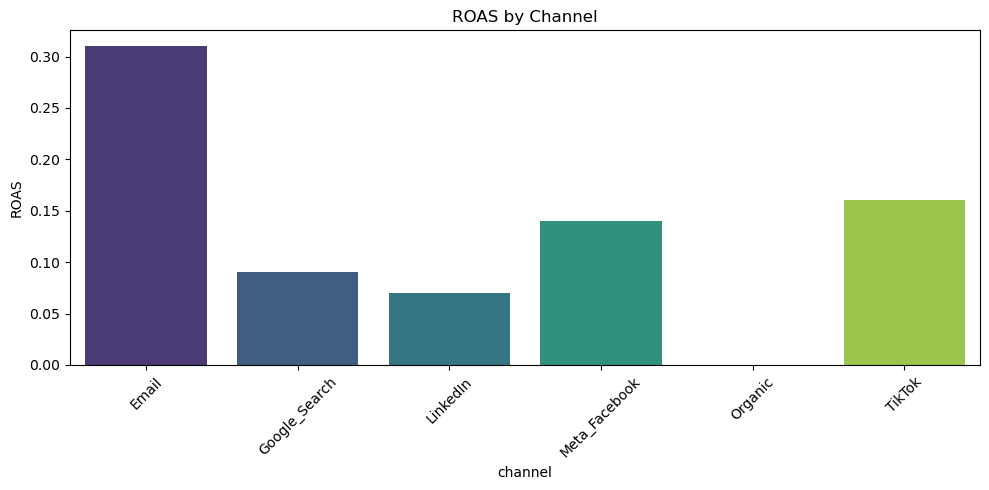

ROAS Graph Saved ✅


In [23]:
# Graph (ROAS By Channel)

plt.figure(figsize=(10,5))
sns.barplot(data=roas, x='channel', y='ROAS',
            hue='channel', legend=False, palette='viridis')
plt.title('ROAS by Channel')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r'C:\Users\HP\Desktop\Project 1 - Marketing attribution\outputs\roas_by_channel.png')
plt.show()
print("ROAS Graph Saved ✅")

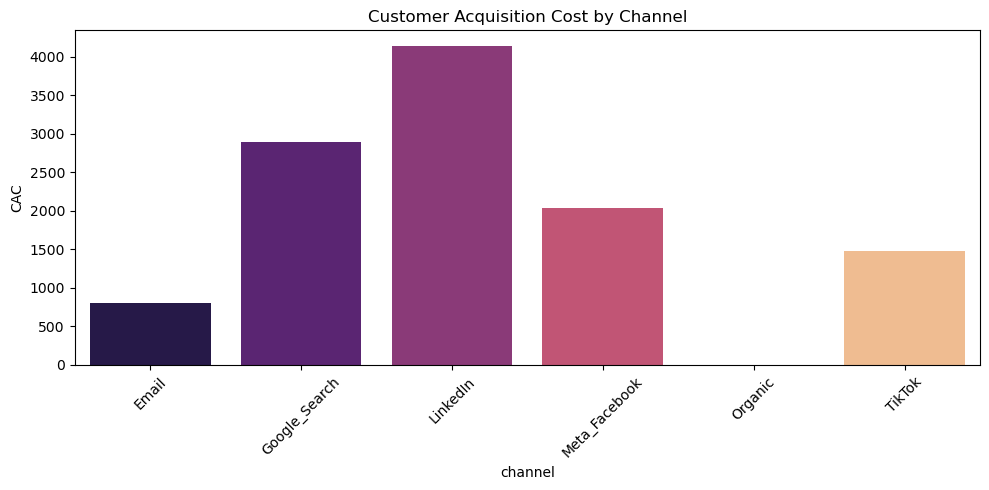

CAC Graph Saved ✅


In [25]:
# Graph ( CAC By Channel )

plt.figure(figsize=(10,5))
sns.barplot(data=cac, x='channel', y='CAC',
            hue='channel', legend=False, palette='magma')
plt.title('Customer Acquisition Cost by Channel')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r'C:\Users\HP\Desktop\Project 1 - Marketing attribution\outputs\cac_by_channel.png')
plt.show()
print("CAC Graph Saved ✅")

In [29]:

roas['ROAS'] = roas['ROAS'].replace([float('inf'), float('-inf')], 0)
print("ROAS Fixed ✅")
print(roas[['channel', 'total_spend', 'total_revenue', 'ROAS']])

ROAS Fixed ✅
         channel  total_spend  total_revenue  ROAS
0          Email     45909.35       14329.86  0.31
1  Google_Search    483302.68       43583.44  0.09
2       LinkedIn    252163.24       16716.83  0.07
3  Meta_Facebook    304221.15       41564.63  0.14
4        Organic         0.00       16696.59  0.00
5         TikTok    150570.08       24587.92  0.16


In [27]:
# Master Table Save

roas.to_csv(r'C:\Users\HP\Desktop\Project 1 - Marketing attribution\Data\Processed\kpi_master_table.csv', index=False)
print("KPI Master Table Saved ✅")
print(roas)

KPI Master Table Saved ✅
         channel  total_spend  total_clicks   CPC  total_conversions      CAC  \
0          Email     45909.35         33527  1.37                 57   805.43   
1  Google_Search    483302.68        333174  1.45                167  2894.03   
2       LinkedIn    252163.24        192338  1.31                 61  4133.82   
3  Meta_Facebook    304221.15        225900  1.35                149  2041.75   
4        Organic         0.00         52863  0.00                 64     0.00   
5         TikTok    150570.08        110630  1.36                102  1476.18   

   total_revenue  ROAS  
0       14329.86  0.31  
1       43583.44  0.09  
2       16716.83  0.07  
3       41564.63  0.14  
4       16696.59   inf  
5       24587.92  0.16  
